## Setup

In [4]:
install.packages('R.utils')
install.packages('future.apply')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’




In [5]:
library(dplyr)
library(data.table)
library(stringr)

In [2]:
## download meQTLs (FDR < 0.05)
system('wget https://zenodo.org/records/8047777/files/meQTL_full.txt.gz')
## downalod heritability results
system('wget https://zenodo.org/records/8047777/files/ACE.txt.gz')

## process blood mQTL heritabilities
- keep hsq p-value < 0.05
- see: https://zenodo.org/records/8047777
- A, A_95CI: Point estimate and 95% CI of variance proportion explained by additive genetic factors (i.e. narrow-sense heritability).

In [6]:
## load hsq data
hsq <- fread('ACE.txt.gz')

In [7]:
library(tidyr)

hsq_fx <-
hsq %>% 
    separate(A_95CI, into = c("A_LCI", "A_UCI"), sep = ",") %>%
    mutate(
        A_LCI = as.numeric(gsub("\\[", "", A_LCI)),
        A_UCI = as.numeric(gsub("\\]", "", A_UCI)),
        hsq_se = (A_UCI - A_LCI) / (2*1.96),
        hsq_p  = 2 * (1 - pnorm(abs( A / hsq_se )))
    )

hsq_fx %>% head

,CpG,A,A_LCI,A_UCI,C,C_95CI,E,E_95CI,hsq_se,hsq_p
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,cg18478105,7.3849e-03,1.6957e-30,0.20551,7.9424e-15,"[1.5945e-43,0.15339]",0.99262,"[0.79449,1]",0.05242602,0.8879779691
2,cg14361672,2.4464e-11,5.6873e-44,0.39112,2.2557e-01,"[6.9115e-40,0.36838]",0.77443,"[0.63162,0.92695]",0.09977551,0.9999999998
3,cg01763666,3.1474e-01,4.4977e-32,0.73088,3.6924e-01,"[1.385e-26,0.66341]",0.31602,"[0.23154,0.42936]",0.18644898,0.0913966899
4,cg02115394,5.4742e-01,1.3057e-01,0.72798,7.6601e-02,"[7.2476e-27,0.42542]",0.37597,"[0.2719,0.52076]",0.15240051,0.0003281716
5,cg13417420,3.7790e-01,8.8486e-02,0.51850,1.6660e-14,"[6.3181e-43,0.24324]",0.62210,"[0.4815,0.78218]",0.10969745,0.0005712079
6,cg26724186,5.7723e-11,1.5322e-42,0.16148,1.3165e-12,"[4.6619e-43,0.14523]",1.00000,"[0.83855,1]",0.04119388,0.9999999989


In [8]:
cpgs_blood_herit = hsq_fx %>% filter(hsq_p < 0.05) %>% pull(CpG)
length(cpgs_blood_herit)

[1] 198373

## Process blood meQTL sumstats
- see here: https://epicmeqtl.kcl.ac.uk/. EPIC DB reports the results of a meQTL analysis at 724,499 CpGs profiled with the Illumina Infinium MethylationEPIC array in 2,358 blood samples from three UK cohorts
- GRCh37

In [9]:
## load meQTLs (cis only)
blood <- fread('meQTL_full.txt.gz') %>% filter(type == 'cis')  

In [10]:
## get top meQTL for each LD-clump withing each CpG site & heritable CpGs
blood_top1 <-
blood %>% 
    group_by(CpG, LD_clump) %>%
    slice_min(order_by = `p-value`, n = 1, with_ties = FALSE) %>% 
    ungroup %>%
    filter(CpG %in% cpgs_blood_herit) 

blood_top1 %>% dim
blood_top1 %>% head

[1] 471927     16

SNP,CpG,type,beta,se,p-value,n_studies,n_samples,effects,FDR,chr_cpg,pos_cpg,chr_snp,pos_snp,MAF,LD_clump
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>
8:133094740_T_C,cg00000596,cis,-0.699190,0.074354,5.61e-21,2,1531,?-?-?,0,8,133098502,8,133094740,0.07123155,8:133100786_G_A
19:54696855_CAAAAA_C,cg00000714,cis,0.359341,0.038806,2.17e-20,3,1939,+++??,0,19,54695678,19,54696855,0.19077757,19:54695163_T_C
19:54718154_T_G,cg00000714,cis,-0.473911,0.048352,1.19e-22,3,1728,?---?,0,19,54695678,19,54718154,0.38518355,19:54706680_C_A
8:86426423_T_TA,cg00001099,cis,-0.275251,0.035964,2.05e-14,3,1728,?---?,0,8,87081553,8,86426423,0.41071565,8:86138060_A_G
8:87045905_A_C,cg00001099,cis,-0.313490,0.031836,7.55e-23,4,2161,--?--,0,8,87081553,8,87045905,0.26359203,8:86997163_G_C
8:87068209_CTG_CTGTG,cg00001099,cis,0.568869,0.037359,2.60e-52,2,1545,?++??,0,8,87081553,8,87068209,0.32919094,8:87059016_A_G


[1] "# of CpGs: 115281"


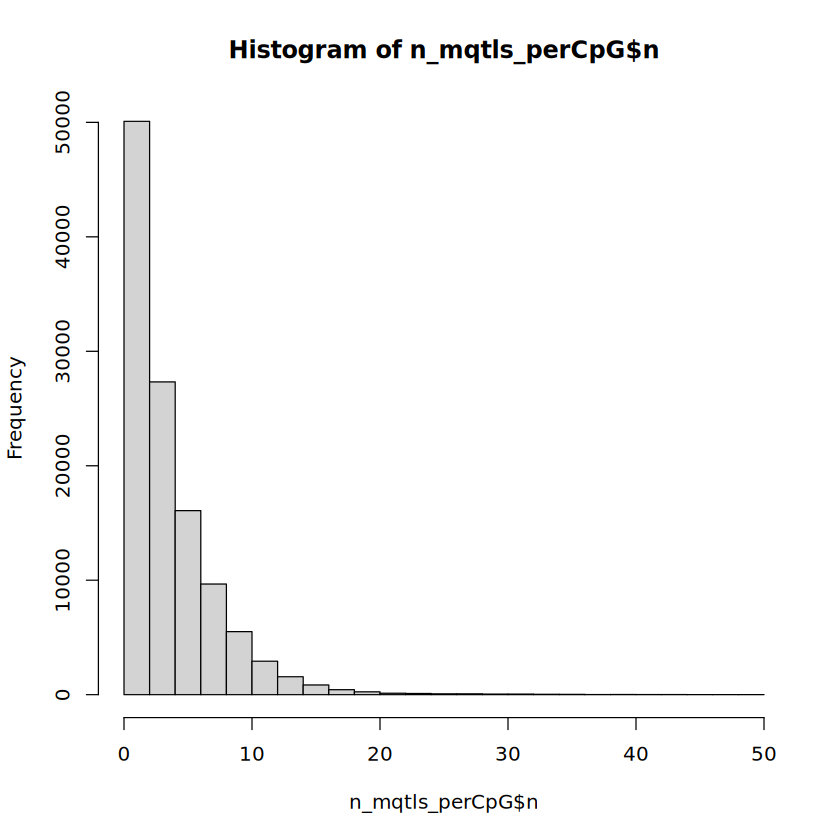

In [11]:
## how many mQTls per CpG? 
n_mqtls_perCpG <- blood_top1 %>% group_by(CpG) %>% summarise(n = n_distinct(LD_clump), .groups = "drop")
print(paste0('# of CpGs: ', nrow(n_mqtls_perCpG)))
hist(n_mqtls_perCpG$n)

## Make score.in files
- see: https://zenodo.org/records/8047777 *SNP: MeQTL SNP ID in the format of chr:pos_A1_A2, where A2 is the effect allele*.

In [ ]:
# example:
# SNP     COUNTED OTHER   enet
# 17:20665682:T:C C       T        0.00554
# 17:20669790:T:C C       T        0.00440


In [12]:
## for all cpgs
score_in <- 
blood_top1 %>% 
    select(c('SNP', 'beta', 'CpG')) %>% rename(top1_ldcl = beta) %>%
    mutate(SNP = gsub("_", ":", SNP)) %>%
    separate(SNP, , into = c(NA, NA, "OTHER", "COUNTED"), sep = ":", remove = F, extra = 'drop') %>%
    filter( str_detect(COUNTED, "A|C|T|G") & str_detect(OTHER, "A|C|T|G")) %>%
    select(c(1,3,2,4,5))

score_in %>% dim
score_in %>% head

[1] 471804      5

SNP,COUNTED,OTHER,top1_ldcl,CpG
<chr>,<chr>,<chr>,<dbl>,<chr>
8:133094740:T:C,C,T,-0.699190,cg00000596
19:54696855:CAAAAA:C,C,CAAAAA,0.359341,cg00000714
19:54718154:T:G,G,T,-0.473911,cg00000714
8:86426423:T:TA,TA,T,-0.275251,cg00001099
8:87045905:A:C,C,A,-0.313490,cg00001099
8:87068209:CTG:CTGTG,CTGTG,CTG,0.568869,cg00001099


In [50]:
library(dplyr)
library(data.table)
library(future.apply)

# setup output folder
path0 <- "EPICDB.BLOOD.METHYL.HERIT/scores/input"
dir.create(path0, recursive = TRUE, showWarnings = FALSE)

cpgs <- unique(score_in$CpG)

# set number of cores
plan(multisession, workers = parallel::detectCores() -1)

#  make .score.in file for cpg i
future_lapply(cpgs, function(cpg_i) {
    
    score_in_i <- score_in %>%
        filter(CpG == cpg_i) %>%
        select(1:4)
    
    score_in_i_path <- file.path(path0, paste0(cpg_i, ".score.in"))
    
    fwrite(score_in_i, score_in_i_path, sep = "\t")
  
})

In [69]:
## make list of .score.in files
system('ls -1 EPICDB.BLOOD.METHYL.HERIT/scores/input/ > EPICDB.BLOOD.METHYL.HERIT/scores/scores.list')
## make .tar.bz2 
system('tar -cjSf EPICDB.BLOOD.METHYL.HERIT.tar.bz2 EPICDB.BLOOD.METHYL.HERIT')
## upload
system('dx upload EPICDB.BLOOD.METHYL.HERIT.tar.bz2 --dest vasilis/data/ebb/weights/')

## Make imputed methylation scores
- use the EPICDB.BLOOD.METHYL.HERIT/scores/input/cp*.score.in files
- use the merged plink files (created using the 02_me_imputation.ipynb script) - NEEDS TO RUN AGAIN, LOW OVERLAP!
- use the EPICDB.BLOOD.METHYL.HERIT/scores/scores.list : list of score.in files paths
- make a samples x scores matrix for all CpGs, to use with PrediXcan


#### test with the preexisting ukb variants

In [17]:
bim <- fread('/mnt/project/vasilis/data/ebb/qc_imp/new_id/imp_wb_qc_newid_all.bim')

In [18]:
epic_snps <- unique(score_in$SNP)
ukb_snps <- unique(bim$V2)
intersect(epic_snps, ukb_snps) %>% length
length(epic_snps)

[1] 38804

[1] 323249

In [74]:
system('dx upload mwas_07_blood_impute.sh --dest vasilis/SAK_scripts/')

In [ ]:
## run in the command line: 

UKB_bfile="vasilis/data/ebb/qc_imp/new_id/imp_wb_qc_newid_all"
WGT="vasilis/data/ebb/weights/EPICDB.BLOOD.METHYL.HERIT.tar.bz2"
dest="vasilis/data/ebb/scores_blood/"

for batch in {3..50}; do
    dx run swiss-army-knife \
        -iin="vasilis/SAK_scripts/mwas_07_blood_impute.sh" \
        -iin="vasilis/SAK_scripts/mwas_02.1_pred_mat.py" \
        -iin="${UKB_bfile}.bed" \
        -iin="${UKB_bfile}.bim" \
        -iin="${UKB_bfile}.fam" \
        -iin="${WGT}" \
        -icmd="sh mwas_07_blood_impute.sh ${batch}" \
        --tag="imp_${batch}" \
        --instance-type "mem1_ssd1_v2_x36" \
        --destination="${dest}" \
        --brief --yes --priority high
done

## Methylome-wide associations
- use same scripts as in 03_me_association.ipynb; just change the input directory (predictdir) to vasilis/data/ebb/scores_blood & output directory (dest) to vasilis/data/ebb/results_blood/

In [ ]:
### inputs needed: 
## passed by -iin: batch*_predict.txt
## passed by -iin: icd.phe 
## passed by -iin: cov.phe
## passed by -iin: phecode_map.csv
## passed by -iin: mwas_func.py
## passed by -iin: mwas_03.1_assoc.py
## passed by -iin: mwas_03_assoc.sh
## passed by -icmd: $1 batch

In [ ]:
## run in the command line: 

icd="vasilis/data/ebb/phenotypes/icd.phe"
cov="vasilis/data/ebb/phenotypes/cov.phe"
phemap="vasilis/data/ebb/phenotypes/phecode_map.csv"
predictdir_blood="vasilis/data/ebb/scores_blood"
predictdir_brain="vasilis/data/ebb/scores"
dest="vasilis/data/ebb/results_blood/"

for batch in {1..50}; do
    dx run swiss-army-knife \
        -iin="vasilis/SAK_scripts/mwas_03_assoc.sh" \
        -iin="vasilis/SAK_scripts/mwas_03.1_assoc.py" \
        -iin="vasilis/SAK_scripts/mwas_func.py" \
        -iin="${predictdir_blood}/batch${batch}_predict.txt" \
        -iin="${predictdir_brain}/batch${batch}_predict.txt" \
        -iin="${icd}" \
        -iin="${cov}" \
        -iin="${phemap}" \
        -icmd="sh mwas_03_assoc.sh ${batch}" \
        --tag="as_${batch}" \
        --instance-type "mem1_ssd1_v2_x36" \
        --destination="${dest}" \
        --brief --yes --priority high
done
